In [1]:
import os
import sys
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import gc

# [对齐主脚本] 强制显存清理与解决 OpenMP 冲突
torch.cuda.empty_cache()
gc.collect()
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

# 强制路径识别 (确保能够导入项目下的自定义包)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..'))) 

# ========================================================
# 🌟 [核心修改] 完全对齐主训练脚本的配置引入方式
# ========================================================
from configs.grid_config import ENCODER_CONFIGS, CORRECTOR_CONFIGS
from configs.single_grid_config import SEARCH_GRIDS, BASE_CONFIG
from Datasets.processed_datasets.dataset_config import DATASET_GROUPS

from corrector.trainer import CorrectionTrainer
# 导入所有可能的模型以便后续动态实例化
from corrector.corrector_model import *
from database.manager import SchoolwareDB
from retriever.engine import DualMetricRetriever
from utils.missing import fill_missing

# 统计特征与时间序列分析库
from scipy.stats import skew, kurtosis, entropy
from statsmodels.tsa.stattools import adfuller

# 机器学习与可解释性库
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, r2_score, classification_report
import shap

In [3]:
# ==========================================
# 1. 解析路径与读取超参数
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 🌟 您可以输入具体的文件路径(best_model.pth) 或 实验文件夹路径
INPUT_PATH = r"results\dual_source_experiment_0319_0\chronos_bolt_tiny\advanced_hybrid_math\dual_fusion_large\run_000_8d5d315f\best_model.pth"

# 统一分隔符并去除首尾空字符
clean_path = INPUT_PATH.strip().replace('\\', '/')
path_parts = clean_path.split('/')

if path_parts[-1].endswith('.pth'):
    EXP_DIR = "/".join(path_parts[:-1])
    CHECKPOINT_PATH = INPUT_PATH
    parts_for_parsing = path_parts[:-1]
else:
    EXP_DIR = clean_path
    CHECKPOINT_PATH = os.path.join(EXP_DIR, "best_model.pth")
    parts_for_parsing = path_parts

JSON_PATH = os.path.join(EXP_DIR, "hyperparams.json")

# 根据结构倒推提取配置
run_id = parts_for_parsing[-1]         
corrector_name = parts_for_parsing[-2] 
encoder_name = parts_for_parsing[-3]   
target_tsfm = parts_for_parsing[-4]    

print(f"📂 实验目录: {EXP_DIR}")
print(f"🔍 路径解析成功: TSFM=[{target_tsfm}], Encoder=[{encoder_name}], Corrector=[{corrector_name}]")

# 读取 JSON
if not os.path.exists(JSON_PATH):
    raise FileNotFoundError(f"❌ 找不到超参数文件: {JSON_PATH}")
with open(JSON_PATH, "r") as f:
    loaded_params = json.load(f)
print("✅ 成功加载 hyperparams.json")

# 重建基础 train_config
train_config = BASE_CONFIG.copy()
train_config.update(loaded_params)
train_config['target_tsfm_filter'] = target_tsfm
train_config['data_root'] = "correction_datasets_double_res_0" 

# 获取数据集划分
train_group = loaded_params.get("train_group", "lotsa_train_clean")
test_group = loaded_params.get("test_group", "ge_test_all")
TRAIN_DATASETS = DATASET_GROUPS.get(train_group, [train_group])
TEST_DATASETS = DATASET_GROUPS.get(test_group, [test_group])
train_config['train_datasets_list'] = TRAIN_DATASETS
train_config['test_datasets_list'] = TEST_DATASETS

# ==========================================
# 2. 🌟 从项目源文件提取特定 model_config 模板
# ==========================================
if corrector_name not in CORRECTOR_CONFIGS:
    raise ValueError(f"❌ 解析到的 Corrector '{corrector_name}' 不在 configs.grid_config 列表中！")

# 获取模型对应的参数模板
template_config = CORRECTOR_CONFIGS[corrector_name]
model_config = {}

# 1. 按照模板字典中的键去 json 文件里拿值，如果 json 里没有，就保留模板的默认值
for key, default_value in template_config.items():
    model_config[key] = loaded_params.get(key, default_value)

# 2. 动态注入模型必需的 embed_dim (这是根据 encoder 确定的物理维度，不可或缺)
embed_dim = 128
if encoder_name == 'hybrid_math': embed_dim = 798
if encoder_name == 'advanced_hybrid_math': embed_dim = 112
model_config['embed_dim'] = loaded_params.get('embed_dim', embed_dim)

# 3. 动态注入可能需要的通用长度参数 (安全起见从 json 中补充)
for k in ['pred_len', 'context_len', 'top_k']:
    if k in loaded_params and k not in model_config:
        model_config[k] = loaded_params[k]
model_config['use_learnable_gate'] = False
print(f"🔧 最终提取的 Model Config: {model_config}")

# ==========================================
# 3. 模型工厂实例化与权重加载
# ==========================================
def get_corrector_model(config):
    arch = config.get("corrector_arch")
    MODEL_MAP = {
        "standard_transformer": StandardTransformerCorrector,
        "similarity_weighted": SimilarityWeightedCorrector,
        "linear": LinearWeightedCorrector, 
        "mlp": MLPCorrector,
        "BSA1": WeightedBaselineCorrector, 
        "BSA2": LightWeightMetaCorrector,
        "learnable_weighted": LearnableWeightedCorrector, 
        "zero": ZeroCorrector,
        "deep_transformer": DeepTransformerCorrector,
        "attention": AttentionCorrector,
        "dual_source_fusion": DualSourceFusionCorrector,
        "dual_set_mlp": DualSourceSetMLPCorrector,
        "dual_gated_mlp": DualSourceGatedMLPCorrector,
        "dual_res_mlp": DualSourceResMLPCorrector,
        "mean_retrieval": MeanRetrievalCorrector,
        "global_bias": GlobalBiasCorrector,
        "local_ar": LocalResARCorrector,
        "dual_frozen_set_mlp": RandomFrozenEncoderSetMLPCorrector,
        "semantic_router" : SemanticRouterCorrector,
        "intra_inter_router": IntraInterRouterCorrector,
        "dual_latent_cross_attn": DualLatentCrossAttnCorrector,
    }
    if arch not in MODEL_MAP:
        if arch == "std_tf": return StandardTransformerCorrector(config)
        raise ValueError(f"Unknown corrector architecture: {arch}")
    return MODEL_MAP[arch](config)

print(f"🧠 正在调用模型工厂实例化模型...")
model = get_corrector_model(model_config).to(DEVICE)

print(f"📥 正在加载最优权重: {CHECKPOINT_PATH}")
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

# ==========================================
# 4. 实例化底层引擎并构建数据流水线
# ==========================================
# ==========================================
# 4. 实例化底层引擎并构建数据流水线
# ==========================================
# 🌟 从项目配置中获取该编码器的完整配置（包含 ckpt_path 等）
db_config = ENCODER_CONFIGS[encoder_name].copy()
db_config['data_dir'] = train_config['data_root']
db_config['context_len'] = 512

print("📊 正在调用 CorrectionTrainer 构建底层数据库与全量加载器...")
trainer = CorrectionTrainer(
    model=model,
    model_config=model_config,
    db_config=db_config,
    train_config=train_config,
    preloaded_data=None 
)

if not hasattr(trainer, 'val_loaders') or not trainer.val_loaders:
    trainer.build_loaders()

print("✅ 实验环境完美复现，模型与数据准备完毕！")

📂 实验目录: results/dual_source_experiment_0319_0/chronos_bolt_tiny/advanced_hybrid_math/dual_fusion_large/run_000_8d5d315f
🔍 路径解析成功: TSFM=[chronos_bolt_tiny], Encoder=[advanced_hybrid_math], Corrector=[dual_fusion_large]
✅ 成功加载 hyperparams.json
🔧 最终提取的 Model Config: {'corrector_arch': 'dual_source_fusion', 'd_model': 256, 'n_heads': 8, 'n_layers': 2, 'dropout': 0, 'use_rank_encoding': True, 'use_vibe_features': 0, 'embed_dim': 112, 'top_k': 50, 'use_learnable_gate': False}
🧠 正在调用模型工厂实例化模型...
📥 正在加载最优权重: results\dual_source_experiment_0319_0\chronos_bolt_tiny\advanced_hybrid_math\dual_fusion_large\run_000_8d5d315f\best_model.pth
📊 正在调用 CorrectionTrainer 构建底层数据库与全量加载器...
🚀 [Trainer] Device: cuda | Patience: 10
🛠️ 误差检索度量机制: COSINE
🛠️ 初始化编码器: [advanced_hybrid_math]
🔍 模式 [TEMPORAL_PER_SEQ] 正在加载数据...
🧮 正在动态计算样本难度分位数 (sMAPE Quantiles)...
📊 数据加载完毕！载入的训练样本总数: 109273
🏗️ 构建向量数据库...


Retrieving: 100%|██████████| 17/17 [00:02<00:00,  6.80it/s]

✅ 实验环境完美复现，模型与数据准备完毕！


In [4]:
# ==========================================
# 封装推断提取与 GPU 误差计算逻辑 (对齐 analysis_double_res.ipynb)
# ==========================================
def extract_tensors_from_loaders(loader_list, desc_prefix=""):
    all_histories, all_local_residuals = [], []
    all_base_smapes, all_model_smapes, all_local_smapes = [], [], [] # 🌟 新增 local 容器
    
    with torch.no_grad():
        for loader in loader_list:
            for batch in tqdm(loader, desc=f"Inferencing {desc_prefix}"):
                # 1. 提取基础特征
                t_hist = batch['history'].to(DEVICE).float().squeeze(1)
                t_emb = batch['sample_embedding'].to(DEVICE).squeeze(1).float()
                c_embs = batch['retrieved_context'].to(DEVICE).float()
                c_res = batch['retrieved_residual'].to(DEVICE).float()
                target_res_scaled = batch['target_residual'].to(DEVICE).squeeze(1).float()
                truth = batch['truth'].to(DEVICE).squeeze(1).float()
                scale = batch['scale'].to(DEVICE).view(-1, 1).float()
                valid_lens = batch['valid_len'].to(DEVICE)
                B = t_hist.shape[0]
                
                t_err_emb = batch.get('sample_err_embedding')
                if t_err_emb is not None: t_err_emb = t_err_emb.to(DEVICE).squeeze(1).float()
                c_err_embs = batch.get('retrieved_err_context')
                if c_err_embs is not None: c_err_embs = c_err_embs.to(DEVICE).float()
                    
                target_local_res = batch.get('local_residual')
                if target_local_res is not None: 
                    target_local_res = target_local_res.to(DEVICE).float()
                    if target_local_res.dim() == 3: target_local_res = target_local_res.squeeze(1)
                    target_local_res = target_local_res.view(B, -1)
                    local_res_np = target_local_res.cpu().numpy() 
                else:
                    local_res_np = np.zeros_like(t_hist.cpu().numpy())
                
                all_histories.append(t_hist.cpu().numpy())
                all_local_residuals.append(local_res_np)

                # =======================================================
                # 🌟 2. 核心数学对齐：定义向量化的 sMAPE 严格掩码计算器
                # =======================================================
                def calc_smape_batch(pred, target, mask):
                    denom = torch.abs(pred) + torch.abs(target)
                    valid_mask = (denom > 1e-5) & mask
                    num = (200 * torch.abs(pred - target) / denom).masked_fill(~valid_mask, 0.0)
                    return num.sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1e-8)

                # 计算基座误差
                target_res_raw = target_res_scaled * scale
                base_pred = truth - target_res_raw
                L = base_pred.shape[1]
                mask = torch.arange(L, device=DEVICE).expand(B, L) < valid_lens.unsqueeze(1)
                
                base_smape = calc_smape_batch(base_pred, truth, mask)
                
                # 计算修正后误差
                pred_norm, info = model(
                    t_emb, c_embs, c_res, t_hist, target_res_scaled,
                    t_err_emb=t_err_emb, c_err_embs=c_err_embs, target_local_res=target_local_res
                )
                pred_out = info.get('pred_res_normalized', pred_norm)
                pred_corr_raw = pred_out * scale
                L_min = min(pred_corr_raw.shape[1], base_pred.shape[1])
                final_pred = base_pred[:, :L_min] + pred_corr_raw[:, :L_min]
                
                corr_smape = calc_smape_batch(final_pred, truth[:, :L_min], mask[:, :L_min])
                
                # =======================================================
                # 🌟 3. 核心数学对齐：强截断假设下的 Local sMAPE 计算
                # =======================================================
                local_smape = torch.zeros(B, device=DEVICE)
                if target_local_res is not None:
                    local_res_raw = target_local_res * scale
                    L_total = local_res_raw.shape[1]
                    
                    local_truth_raw = t_hist * scale 
                    if local_truth_raw.shape[1] < L_total:
                        pad_len = L_total - local_truth_raw.shape[1]
                        local_truth_raw = torch.nn.functional.pad(local_truth_raw, (pad_len, 0))
                    else:
                        local_truth_raw = local_truth_raw[:, -L_total:]
                        
                    local_base_pred_raw = local_truth_raw - local_res_raw
                    
                    # 动态生成右侧对齐的强掩码，仅关注倒数 valid_lens 长度的局部残差！
                    idx_matrix = torch.arange(L_total, device=DEVICE).unsqueeze(0).expand(B, L_total)
                    start_indices = L_total - valid_lens.unsqueeze(1)
                    local_mask = idx_matrix >= start_indices
                    
                    local_smape = calc_smape_batch(local_base_pred_raw, local_truth_raw, local_mask)

                # 展平存入列表
                all_base_smapes.extend(base_smape.view(-1).cpu().tolist())
                all_model_smapes.extend(corr_smape.view(-1).cpu().tolist())
                all_local_smapes.extend(local_smape.view(-1).cpu().tolist())

    return (np.concatenate(all_histories, axis=0), 
            np.concatenate(all_local_residuals, axis=0), 
            np.array(all_base_smapes), 
            np.array(all_model_smapes),
            np.array(all_local_smapes)) # 🌟 额外返回 local sMAPE 数组

print("🏃‍♂️ 正在 Train Group 上执行推断与张量提取...")
train_h, train_lr, train_b_err, train_m_err, train_l_err = extract_tensors_from_loaders([trainer.train_loader], desc_prefix="Train Group")

print("🏃‍♂️ 正在 Test Group 上执行推断与张量提取...")
test_h, test_lr, test_b_err, test_m_err, test_l_err = extract_tensors_from_loaders(list(trainer.val_loaders.values()), desc_prefix="Test Group")

print(f"✅ 数据提取完成! Train: {train_h.shape[0]} 样本 | Test: {test_h.shape[0]} 样本")

🏃‍♂️ 正在 Train Group 上执行推断与张量提取...


Inferencing Train Group: 100%|██████████| 854/854 [00:17<00:00, 49.55it/s]


🏃‍♂️ 正在 Test Group 上执行推断与张量提取...


Inferencing Test Group: 100%|██████████| 65/65 [00:01<00:00, 48.97it/s]

✅ 数据提取完成! Train: 109273 样本 | Test: 8319 样本


In [17]:
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
from tqdm import tqdm

def calculate_shannon_entropy(x, bins=10):
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

# ==========================================
# 1. 历史序列 (原始信号) 特征提取
# ==========================================
def extract_history_features(h):
    """专注于原始时间序列的动力学属性 (趋势、周期、复杂度)"""
    n = len(h)
    if n < 5: return {}
    feats = {}
    
    # 基础统计 (Scale & Volatility)
    feats['mean'] = np.mean(h)
    feats['std'] = np.std(h)
    feats['cv'] = feats['std'] / (np.abs(feats['mean']) + 1e-8)
    feats['ptp'] = np.ptp(h) # 极差 (Peak-to-Peak)
    
    # 宏观趋势与平稳性 (Trend & Stationarity)
    t = np.arange(n)
    feats['trend_slope'] = np.polyfit(t, h, 1)[0]
    try: 
        feats['adf_stat'] = adfuller(h, maxlag=min(10, n//2 - 1))[0]
    except: 
        feats['adf_stat'] = 0.0
        
    # 频域能量 (Frequency Domain)
    fft_vals = np.abs(np.fft.rfft(h - feats['mean']))
    split_idx = max(1, len(fft_vals) // 5) # 前 20% 视为低频
    low_energy = np.sum(fft_vals[:split_idx]**2)
    high_energy = np.sum(fft_vals[split_idx:]**2)
    feats['freq_energy_ratio'] = high_energy / (low_energy + 1e-8)
    
    # 复杂度与自相关 (Complexity)
    feats['autocorr_lag1'] = np.corrcoef(h[:-1], h[1:])[0, 1] if feats['std'] > 1e-5 else 0.0
    feats['shannon_entropy'] = calculate_shannon_entropy(h)
    feats['diff_mad'] = np.mean(np.abs(np.diff(h))) # 一阶差分绝对均值 (高频抖动)
    
    return feats

# ==========================================
# 2. 局部残差 (基座误差) 特征提取
# ==========================================
def extract_residual_features(lr):
    """专注于模型误差的分布属性 (偏差、方差、自相关)，严格剔除左侧 Padding"""
    # 🌟 核心：定位实际的局部验证窗口，剔除左侧补的 0
    non_zero_indices = np.where(np.abs(lr) > 1e-6)[0]
    if len(non_zero_indices) == 0:
        return {
            'bias': 0.0, 'mae': 0.0, 'rmse': 0.0, 
            'skewness': 0.0, 'kurtosis': 0.0, 'error_autocorr': 0.0
        }
    
    # 截取真实的误差片段
    valid_lr = lr[non_zero_indices[0]:]
    n = len(valid_lr)
    feats = {}
    
    # 误差量级 (Error Magnitude)
    feats['bias'] = np.mean(valid_lr)                 # 系统性偏差 (正负代表方向)
    feats['mae'] = np.mean(np.abs(valid_lr))          # 平均绝对误差
    feats['rmse'] = np.sqrt(np.mean(valid_lr**2))     # 均方根误差
    
    # 误差分布形态 (Error Distribution)
    # Skewness 衡量误差是否偏向某一边；Kurtosis 衡量是否经常出现极端大误差点(重尾)
    feats['skewness'] = skew(valid_lr) if n > 3 else 0.0
    feats['kurtosis'] = kurtosis(valid_lr) if n > 3 else 0.0
    
    # 误差自相关 (Error Autocorrelation)
    # 如果误差自相关高，说明基座模型存在严重的“惯性失误” (连续高估/低估)，这非常适合被修正！
    feats['error_autocorr'] = np.corrcoef(valid_lr[:-1], valid_lr[1:])[0, 1] if np.std(valid_lr) > 1e-5 and n > 2 else 0.0
    
    return feats

# ==========================================
# 3. 信号与误差交叉特征提取
# ==========================================
def extract_cross_features(h, lr):
    """专注于信号与误差之间的耦合关系 (信噪比、异方差性)"""
    feats = {}
    
    # 同样需要先剔除 Padding，找到真实长度
    non_zero_indices = np.where(np.abs(lr) > 1e-6)[0]
    if len(non_zero_indices) == 0 or len(h) < len(lr):
        return {'snr': 0.0, 'heteroskedasticity': 0.0, 'sig_err_corr': 0.0}
        
    valid_lr = lr[non_zero_indices[0]:]
    n_lr = len(valid_lr)
    
    # 取出与有效误差完全对应的那段历史信号
    h_recent = h[-n_lr:] 
    
    sig_std = np.std(h_recent)
    err_std = np.std(valid_lr)
    
    # 1. 信噪比 (Signal-to-Noise Ratio): 误差波动相对信号波动的大小
    feats['snr'] = sig_std / (err_std + 1e-8)
    
    if sig_std > 1e-5 and err_std > 1e-5:
        # 2. 信号与误差的直接相关性 (例如：信号上升时，模型是否倾向于低估/高估)
        feats['sig_err_corr'] = np.corrcoef(h_recent, valid_lr)[0, 1]
        
        # 3. 异方差性 (Heteroskedasticity): 信号绝对幅值越大，误差绝对幅值是否也跟着变大？
        feats['heteroskedasticity'] = np.corrcoef(np.abs(h_recent), np.abs(valid_lr))[0, 1]
    else:
        feats['sig_err_corr'] = 0.0
        feats['heteroskedasticity'] = 0.0
        
    return feats

# ==========================================
# 4. 构建 DataFrame
# ==========================================
def build_features_dataframe(h_arr, lr_arr, b_err, m_err, l_err, desc=""):
    print(f"🧩 开始计算 {desc} 的高维解耦特征 (物理信号与残差剥离)...")
    gains = np.array(b_err) - np.array(m_err)
    labels = (gains > 0).astype(int)
    
    feature_list = []
    
    for h, lr, b, m, l_e, gain, label in tqdm(zip(h_arr, lr_arr, b_err, m_err, l_err, gains, labels), total=len(gains), desc=desc):
        # 🌟 分别调用专属的特征提取器
        h_feats = extract_history_features(h)
        lr_feats = extract_residual_features(lr)
        cross_feats = extract_cross_features(h, lr)
        
        # 拼接字典，加上前缀以示区分
        combined = {f"Hist_{k}": v for k, v in h_feats.items()}
        combined.update({f"Err_{k}": v for k, v in lr_feats.items()}) # 残差特征改名为 Err_
        combined.update({f"Cross_{k}": v for k, v in cross_feats.items()})
        
        # 记录基准指标与标签
        combined['Val_Base_Error'] = l_e      
        combined['Future_Base_Error'] = b     
        combined['Future_Corrected_Error'] = m 
        combined['Target_Gain'] = gain
        combined['Label_Worth'] = label
        
        feature_list.append(combined)
        
    return pd.DataFrame(feature_list).fillna(0)

# ==========================================
# 5. 执行生成
# ==========================================
df_train = build_features_dataframe(train_h, train_lr, train_b_err, train_m_err, train_l_err, "Train Group")
df_test = build_features_dataframe(test_h, test_lr, test_b_err, test_m_err, test_l_err, "Test Group")

🧩 开始计算 Train Group 的高维解耦特征 (物理信号与残差剥离)...


Train Group: 100%|██████████| 109273/109273 [03:59<00:00, 456.76it/s]


🧩 开始计算 Test Group 的高维解耦特征 (物理信号与残差剥离)...


Test Group: 100%|██████████| 8319/8319 [00:18<00:00, 461.22it/s]


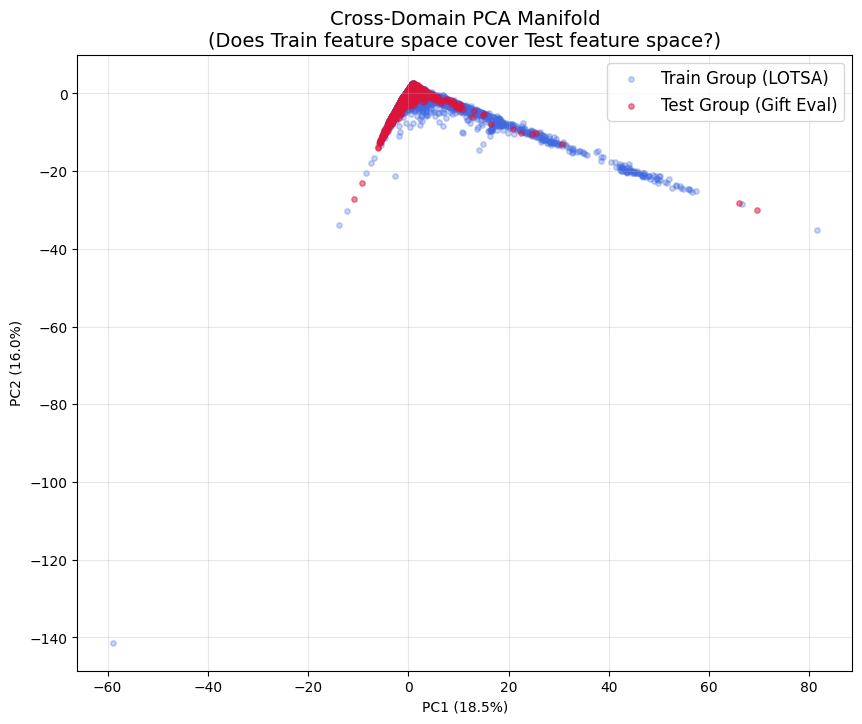

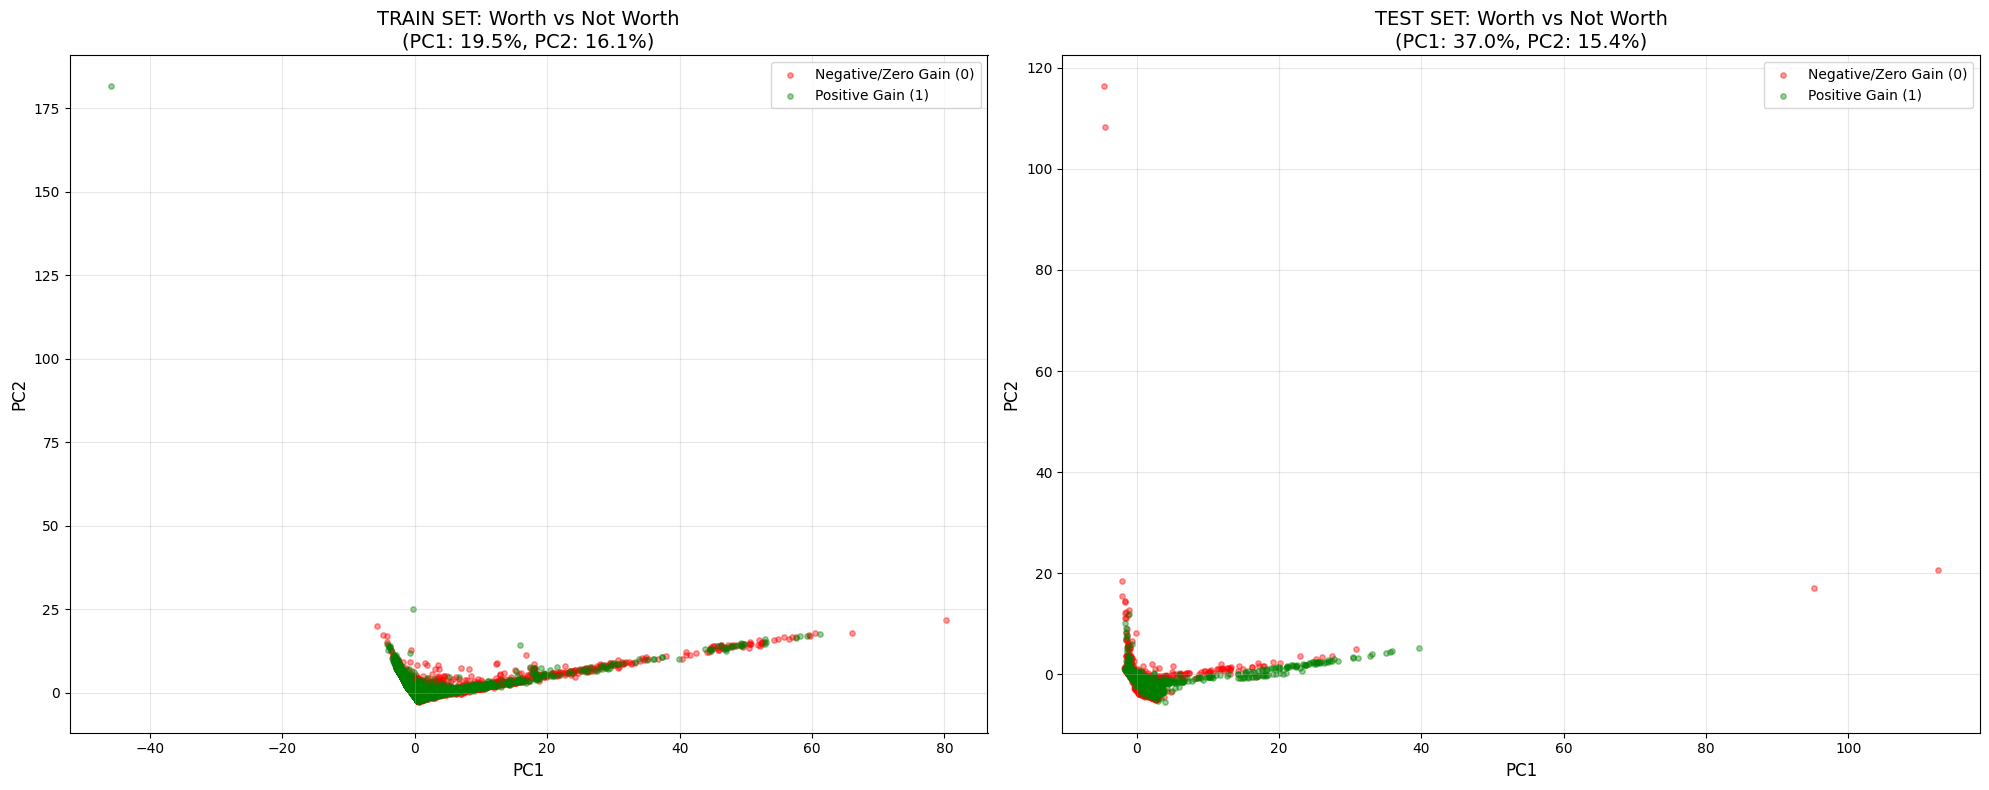

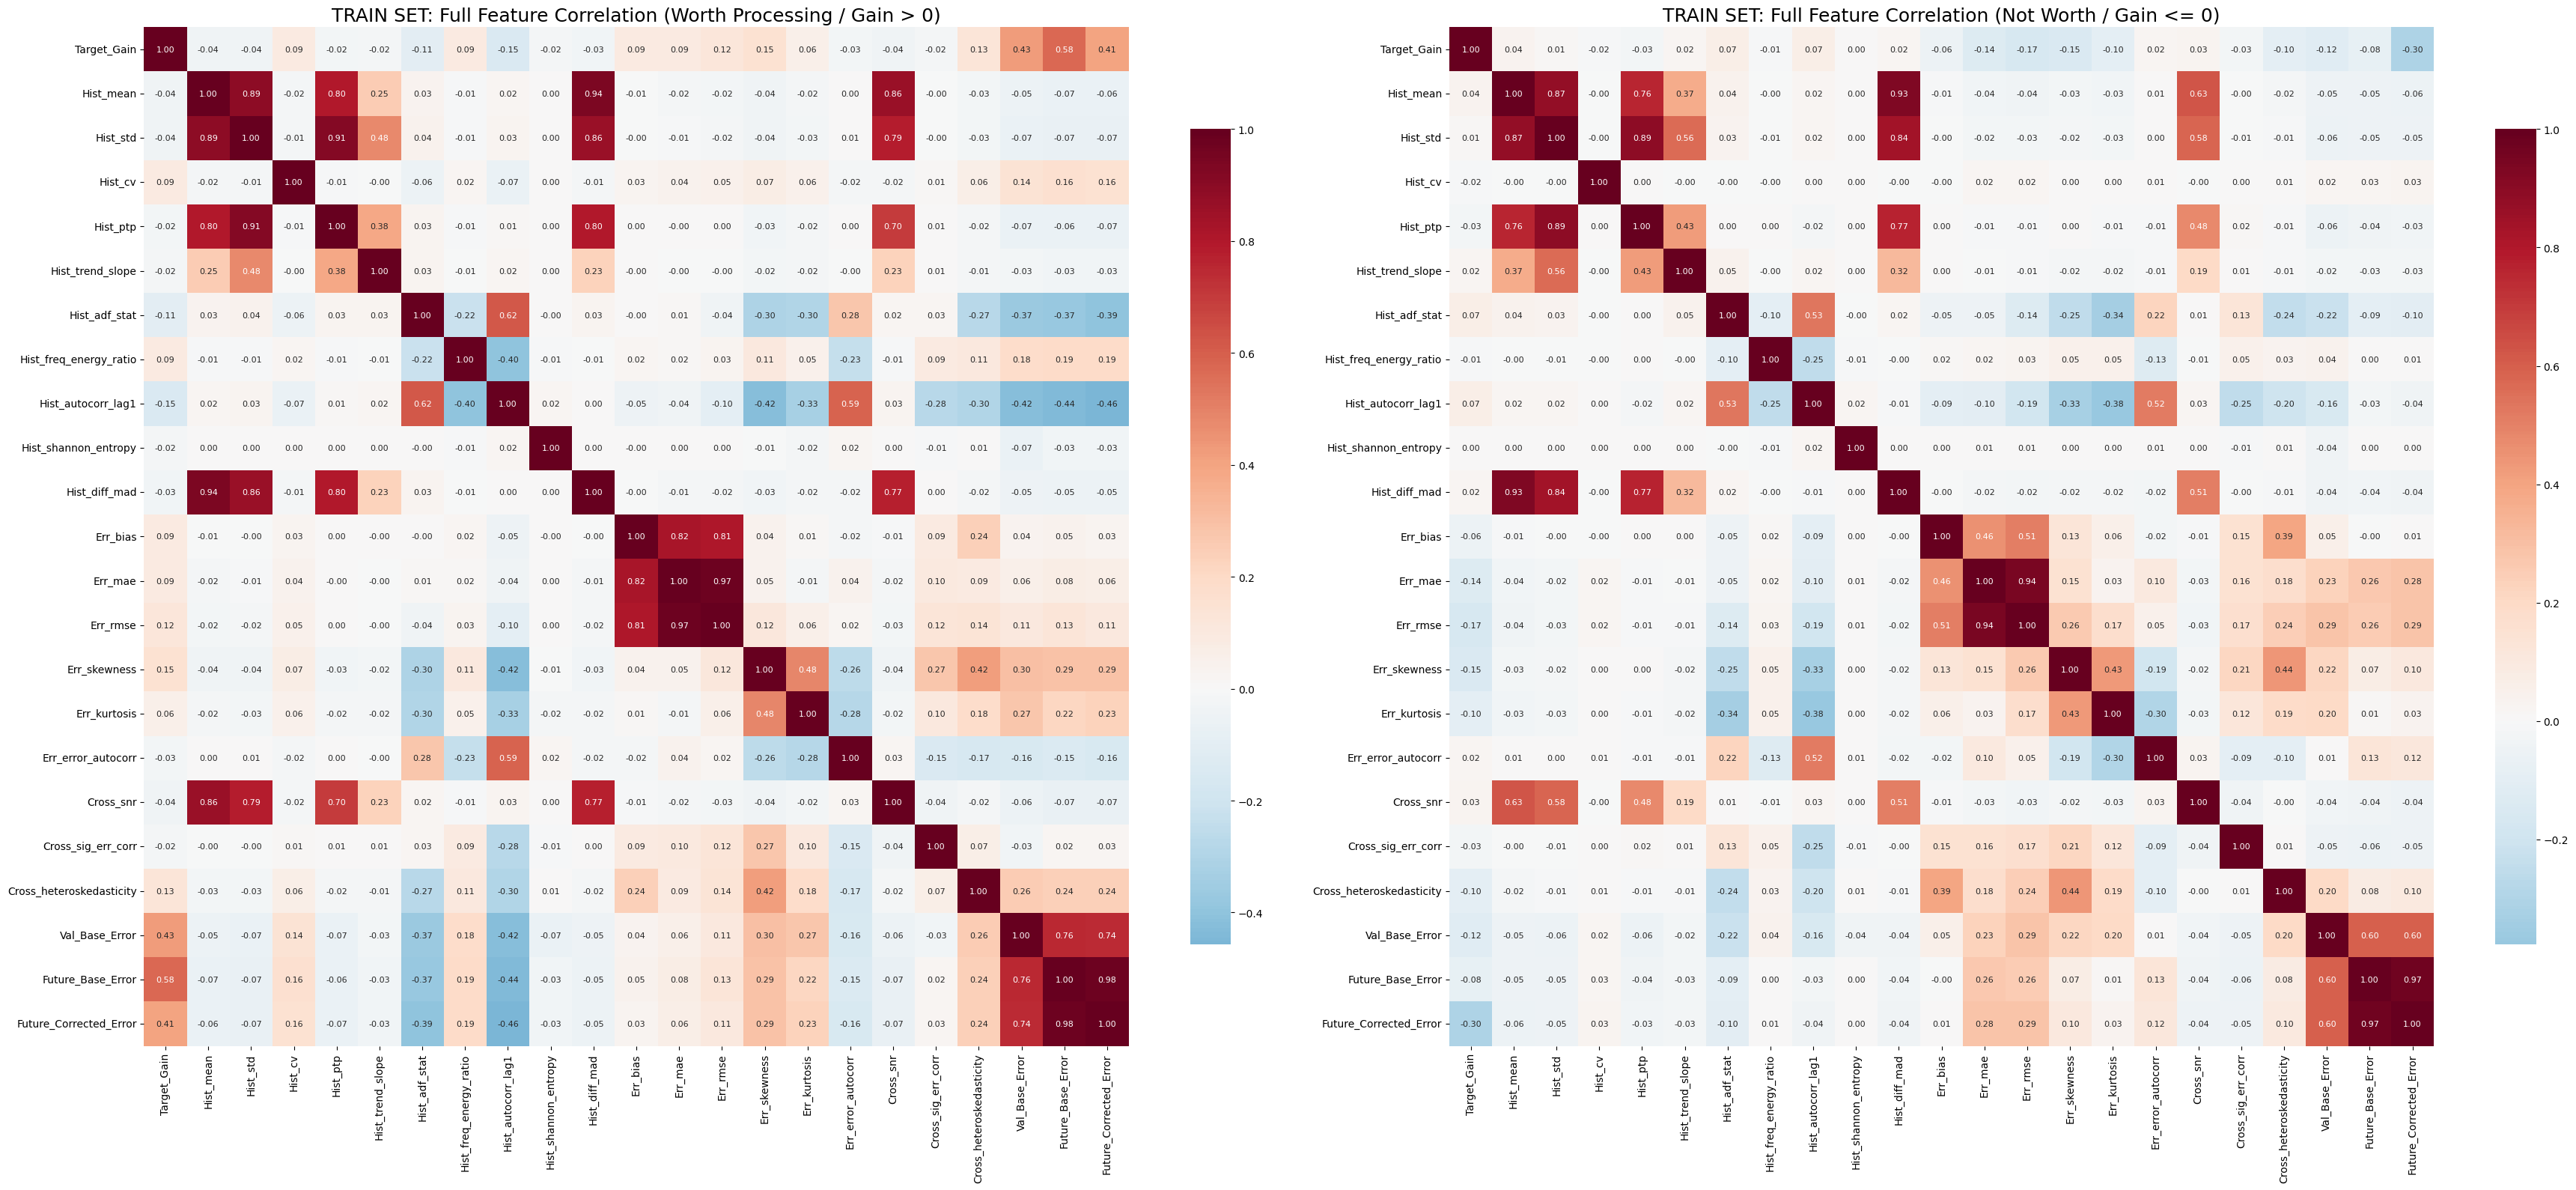

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 提取特征矩阵与标签
X_train_raw = df_train.drop(columns=['Target_Gain', 'Label_Worth'])
X_test_raw = df_test.drop(columns=['Target_Gain', 'Label_Worth'])

y_train_class = df_train['Label_Worth']
y_test_class = df_test['Label_Worth']

# 🌟 必须仅在 Train 上 fit scaler，然后 transform Test (严格防泄漏)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ==========================================
# 图 1: Train vs Test 跨域全局流形图 (Domain Shift)
# ==========================================
X_combined = np.vstack([X_train_scaled, X_test_scaled])
domain_labels = np.array([0]*len(X_train_scaled) + [1]*len(X_test_scaled)) # 0:Train, 1:Test

pca_global = PCA(n_components=2)
X_pca_combined = pca_global.fit_transform(X_combined)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca_combined[domain_labels==0, 0], X_pca_combined[domain_labels==0, 1], 
            color='royalblue', alpha=0.3, s=15, label='Train Group (LOTSA)')
plt.scatter(X_pca_combined[domain_labels==1, 0], X_pca_combined[domain_labels==1, 1], 
            color='crimson', alpha=0.5, s=15, label='Test Group (Gift Eval)')

plt.title("Cross-Domain PCA Manifold\n(Does Train feature space cover Test feature space?)", fontsize=14)
plt.xlabel(f"PC1 ({pca_global.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_global.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 图 2: 域内子集 PCA (正负收益分离度: Train & Test)
# ==========================================
# 分别在 Train 和 Test 上做独立的 PCA，最大化展现各自内部的方差
pca_train = PCA(n_components=2)
X_pca_train = pca_train.fit_transform(X_train_scaled)

pca_test = PCA(n_components=2)
X_pca_test = pca_test.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 子图 2.1: Train 集内的正负收益分离
axes[0].scatter(X_pca_train[y_train_class==0, 0], X_pca_train[y_train_class==0, 1], 
                color='red', alpha=0.4, s=15, label='Negative/Zero Gain (0)')
axes[0].scatter(X_pca_train[y_train_class==1, 0], X_pca_train[y_train_class==1, 1], 
                color='green', alpha=0.4, s=15, label='Positive Gain (1)')
axes[0].set_title(f"TRAIN SET: Worth vs Not Worth\n(PC1: {pca_train.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca_train.explained_variance_ratio_[1]*100:.1f}%)", fontsize=14)
axes[0].set_xlabel("PC1", fontsize=12)
axes[0].set_ylabel("PC2", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 子图 2.2: Test 集内的正负收益分离
axes[1].scatter(X_pca_test[y_test_class==0, 0], X_pca_test[y_test_class==0, 1], 
                color='red', alpha=0.4, s=15, label='Negative/Zero Gain (0)')
axes[1].scatter(X_pca_test[y_test_class==1, 0], X_pca_test[y_test_class==1, 1], 
                color='green', alpha=0.4, s=15, label='Positive Gain (1)')
axes[1].set_title(f"TEST SET: Worth vs Not Worth\n(PC1: {pca_test.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca_test.explained_variance_ratio_[1]*100:.1f}%)", fontsize=14)
axes[1].set_xlabel("PC1", fontsize=12)
axes[1].set_ylabel("PC2", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 图 3: 极致放大、包含全量特征的巨型相关性热力图
# ==========================================
df_pos = df_train[df_train['Label_Worth'] == 1].drop(columns=['Label_Worth'])
df_neg = df_train[df_train['Label_Worth'] == 0].drop(columns=['Label_Worth'])

# 🌟 动态获取全部特征列，并强制将 'Target_Gain' 放在列表第一位，方便我们直接看第一行/第一列
all_cols = ['Target_Gain'] + [col for col in df_train.columns if col not in ['Target_Gain', 'Label_Worth']]

# 🌟 显著增加画布尺寸至 36x16，确保几十个特征不会重叠
fig, axes = plt.subplots(1, 2, figsize=(36, 16))

# 🌟 开启 annot=True，保留两位小数，缩小字体 (size=8) 以适配超大矩阵
sns.heatmap(df_pos[all_cols].corr(), cmap='RdBu_r', center=0, ax=axes[0], 
            annot=True, fmt=".2f", annot_kws={"size": 8}, cbar_kws={'shrink': .8})
axes[0].set_title("TRAIN SET: Full Feature Correlation (Worth Processing / Gain > 0)", fontsize=18)

sns.heatmap(df_neg[all_cols].corr(), cmap='RdBu_r', center=0, ax=axes[1], 
            annot=True, fmt=".2f", annot_kws={"size": 8}, cbar_kws={'shrink': .8})
axes[1].set_title("TRAIN SET: Full Feature Correlation (Not Worth / Gain <= 0)", fontsize=18)

plt.tight_layout()
plt.show()

🛡️ 严格隔离未来数据！以下是模型所使用的全部合规历史特征：
------------------------------------------------------------
  1. Hist_mean
  2. Hist_std
  3. Hist_cv
  4. Hist_ptp
  5. Hist_trend_slope
  6. Hist_adf_stat
  7. Hist_freq_energy_ratio
  8. Hist_autocorr_lag1
  9. Hist_shannon_entropy
 10. Hist_diff_mad
 11. Err_bias
 12. Err_mae
 13. Err_rmse
 14. Err_skewness
 15. Err_kurtosis
 16. Err_error_autocorr
 17. Cross_snr
 18. Cross_sig_err_corr
 19. Cross_heteroskedasticity
 20. Val_Base_Error
📊 跨域测试集 (Test Group) 统计:
   - 正收益 (值得加工) : 1984 个样本 (23.8%)
   - 负收益 (不值得)   : 6335 个样本 (76.2%)
--------------------------------------------------
🌲 正在 Train Group 上执行 5 折交叉验证 (In-domain Validation)...

🏆 [5折 CV 平均成绩对比]
🔸 RandomForest     | AUC: 0.7306 | PR-AP: 0.5753 | R^2: 0.2884
🔸 XGBoost          | AUC: 0.7270 | PR-AP: 0.5664 | R^2: 0.3128
🔸 MLP (Neural Net) | AUC: 0.7099 | PR-AP: 0.5373 | R^2: 0.2142
------------------------------------------------------------

🌲 正在全量 Train Group 上训练最终元学习模型...

🎯 跨域测试集 (Test Group

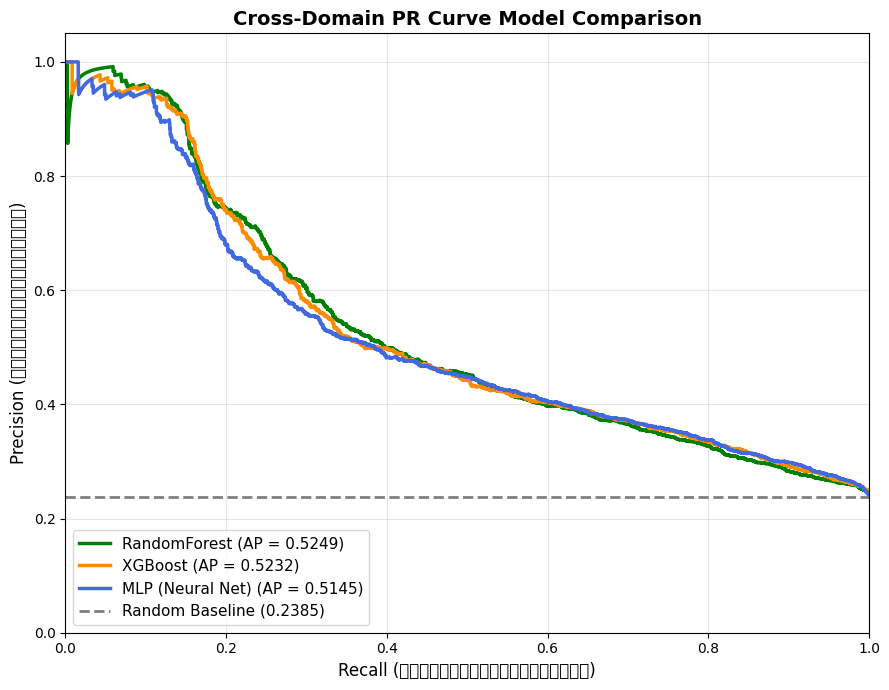


🔬 正在计算 Test Group 的跨域 SHAP 归因 (基于 XGBoost)...


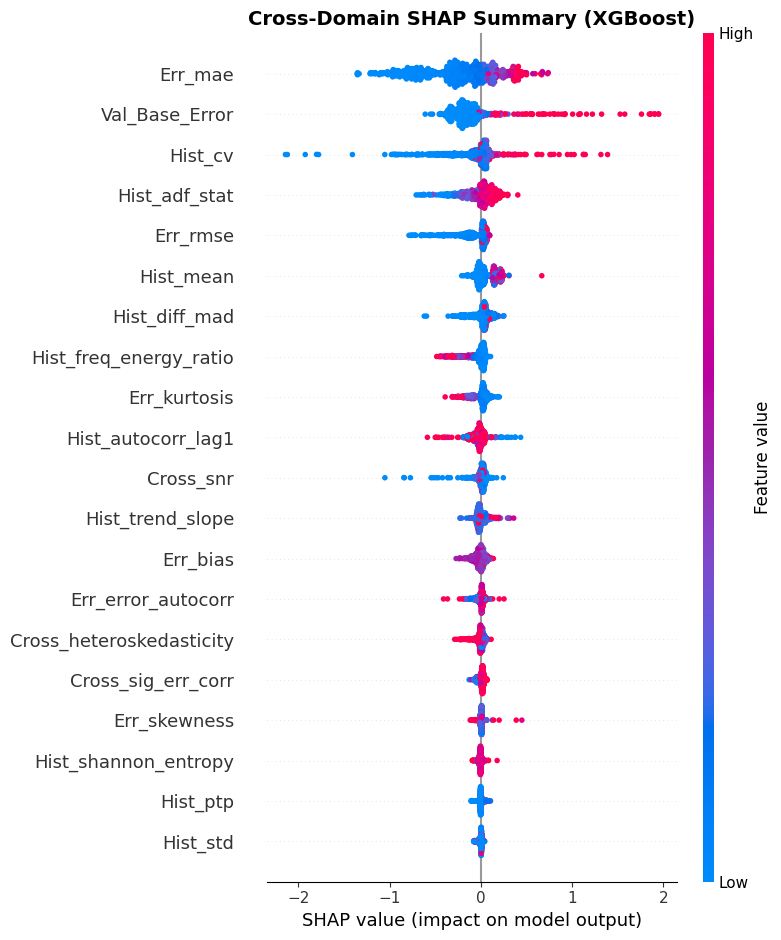

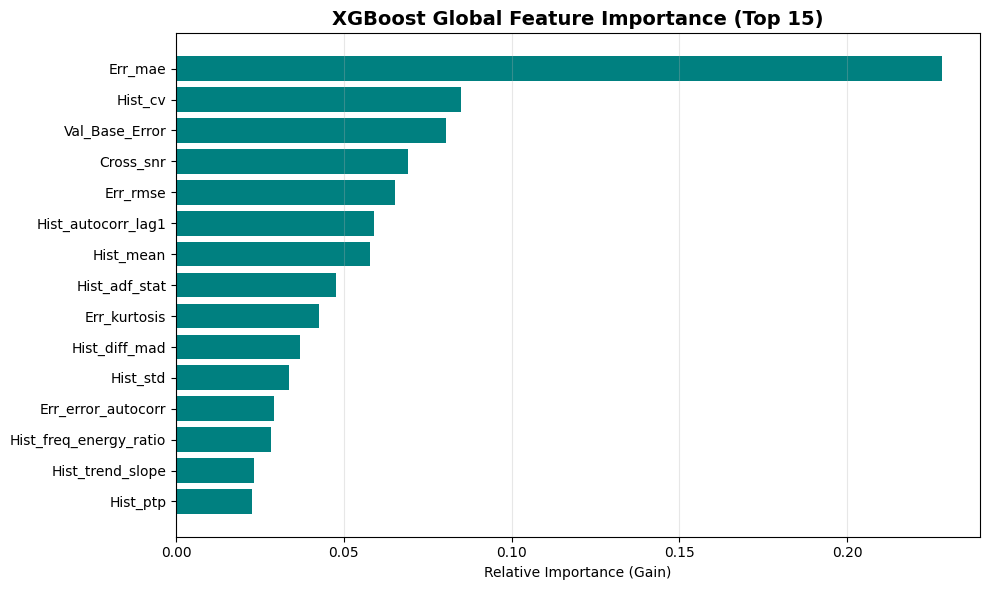

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# ==========================================
# 🌟 0. 严格剥离未来信息与目标标签
# ==========================================
# 定义所有的泄露列、目标列、以及非数值型列
leaky_and_target_cols = [
    'Target_Gain',              # 目标标签 (回归)
    'Label_Worth',              # 目标标签 (分类)
    'Future_Base_Error',        # 🚨 严重泄露：未来窗口的基座误差
    'Future_Corrected_Error',   # 🚨 严重泄露：未来窗口的修正后误差
    'Domain',                   # 非数值元数据
    'Freq_Meta'                 # 非数值元数据
]

# 动态获取实际需要 Drop 的列
cols_to_drop = [c for c in leaky_and_target_cols if c in df_train.columns]

# 提取纯净特征矩阵 (仅限数值特征)
X_train_raw = df_train.drop(columns=cols_to_drop).select_dtypes(include=[np.number])
X_test_raw = df_test.drop(columns=cols_to_drop).select_dtypes(include=[np.number])

y_c_train = df_train['Label_Worth']
y_r_train = df_train['Target_Gain']

y_c_test = df_test['Label_Worth']
y_r_test = df_test['Target_Gain']

# 打印所使用的合规特征列表
print("=" * 60)
print("🛡️ 严格隔离未来数据！以下是模型所使用的全部合规历史特征：")
print("-" * 60)
for i, col in enumerate(X_train_raw.columns):
    print(f" {i+1:2d}. {col}")
print("=" * 60)

# ==========================================
# 0.5 打印跨域测试集 (Test Group) 的正负样本统计
# ==========================================
pos_count = (y_c_test == 1).sum()
neg_count = (y_c_test == 0).sum()
print(f"📊 跨域测试集 (Test Group) 统计:")
print(f"   - 正收益 (值得加工) : {pos_count} 个样本 ({pos_count/len(y_c_test)*100:.1f}%)")
print(f"   - 负收益 (不值得)   : {neg_count} 个样本 ({neg_count/len(y_c_test)*100:.1f}%)")
print("-" * 50)

# 缩放特征（神经网络对缩放极其敏感，严格使用 Train Fit，Test Transform）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ==========================================
# 🌟 定义要对比的模型池 (Random Forest, XGBoost, MLP)
# ==========================================
classifiers = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.05, random_state=42, eval_metric='logloss', n_jobs=-1),
    "MLP (Neural Net)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, alpha=0.001, random_state=42, early_stopping=True)
}

regressors = {
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1),
    "MLP (Neural Net)": MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, alpha=0.001, random_state=42, early_stopping=True)
}

# ==========================================
# 1. 训练集 (Train Group) 域内 5 折交叉验证
# ==========================================
print("🌲 正在 Train Group 上执行 5 折交叉验证 (In-domain Validation)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 用于存储各个模型的 CV 结果
cv_results = {name: {'auc': [], 'ap': [], 'r2': []} for name in classifiers.keys()}

# 1.1 分类 CV
for train_idx, val_idx in skf.split(X_train_scaled, y_c_train):
    X_tr, X_va = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_va = y_c_train.values[train_idx], y_c_train.values[val_idx]
    
    for name, clf in classifiers.items():
        clf.fit(X_tr, y_tr)
        y_prob = clf.predict_proba(X_va)[:, 1]
        cv_results[name]['auc'].append(roc_auc_score(y_va, y_prob))
        cv_results[name]['ap'].append(average_precision_score(y_va, y_prob))

# 1.2 回归 CV
for train_idx, val_idx in kf.split(X_train_scaled):
    X_tr, X_va = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_va = y_r_train.values[train_idx], y_r_train.values[val_idx]
    
    for name, reg in regressors.items():
        reg.fit(X_tr, y_tr)
        y_pred = reg.predict(X_va)
        cv_results[name]['r2'].append(r2_score(y_va, y_pred))

# 打印 CV 结果对比
print("\n🏆 [5折 CV 平均成绩对比]")
for name in classifiers.keys():
    print(f"🔸 {name:16s} | AUC: {np.mean(cv_results[name]['auc']):.4f} | PR-AP: {np.mean(cv_results[name]['ap']):.4f} | R^2: {np.mean(cv_results[name]['r2']):.4f}")
print("-" * 60)

# ==========================================
# 2. 全量训练与跨域泛化验证 (Cross-Domain Test)
# ==========================================
print("\n🌲 正在全量 Train Group 上训练最终元学习模型...")
test_probs = {}
test_metrics = {}

for name in classifiers.keys():
    # 训练全量分类器
    classifiers[name].fit(X_train_scaled, y_c_train)
    # 训练全量回归器
    regressors[name].fit(X_train_scaled, y_r_train)
    
    # 在测试集上进行预测
    y_c_prob = classifiers[name].predict_proba(X_test_scaled)[:, 1]
    y_r_pred = regressors[name].predict(X_test_scaled)
    
    # 记录预测概率以备画图
    test_probs[name] = y_c_prob
    
    # 计算测试集指标
    auc_score = roc_auc_score(y_c_test, y_c_prob)
    ap_score = average_precision_score(y_c_test, y_c_prob)
    r2_val = r2_score(y_r_test, y_r_pred)
    test_metrics[name] = {'auc': auc_score, 'ap': ap_score, 'r2': r2_val}

print("\n🎯 跨域测试集 (Test Group) 泛化能力评估:")
for name, metrics in test_metrics.items():
    print(f"🔹 {name:16s} | AUC: {metrics['auc']:.4f} | PR-AP: {metrics['ap']:.4f} | R^2: {metrics['r2']:.4f}")
print("-" * 60)

# ==========================================
# 3. 绘制跨域 PR 曲线 (Precision-Recall Curve 对比)
# ==========================================
plt.figure(figsize=(9, 7))
colors = {'RandomForest': 'green', 'XGBoost': 'darkorange', 'MLP (Neural Net)': 'royalblue'}

for name in classifiers.keys():
    precision, recall, _ = precision_recall_curve(y_c_test, test_probs[name])
    ap = test_metrics[name]['ap']
    plt.plot(recall, precision, color=colors[name], lw=2.5, label=f'{name} (AP = {ap:.4f})')

# 绘制随机猜测基线
baseline = pos_count / len(y_c_test)
plt.axhline(y=baseline, color='gray', lw=2, linestyle='--', label=f'Random Baseline ({baseline:.4f})')

plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Recall (在未见数据集上找出了多少可被修正的样本)', fontsize=12)
plt.ylabel('Precision (找出来的样本有多大把握是真的正收益)', fontsize=12)
plt.title('Cross-Domain PR Curve Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 4. 跨域 SHAP 分析与特征重要性 (以表现最强的树模型 XGBoost 为例)
# ==========================================
# 神经网络求 SHAP 非常慢，所以我们选取 XGBoost 作为解释对象
best_tree_model = classifiers['XGBoost']
best_tree_name = 'XGBoost'

print(f"\n🔬 正在计算 Test Group 的跨域 SHAP 归因 (基于 {best_tree_name})...")
sample_idx = np.random.choice(X_test_scaled.shape[0], min(800, X_test_scaled.shape[0]), replace=False)
X_test_sampled = X_test_scaled[sample_idx]
X_test_df = pd.DataFrame(X_test_sampled, columns=X_train_raw.columns)

# 使用 TreeExplainer 解释 XGBoost
explainer = shap.TreeExplainer(best_tree_model)
shap_values = explainer.shap_values(X_test_sampled)

# 对于二分类，XGBoost 返回的是单一数组（Log-odds），而 RandomForest 会返回 list，需要兼容
shap_vals_target = shap_values[1] if isinstance(shap_values, list) else shap_values

# 4.1 SHAP 蜂群图
fig = plt.figure(figsize=(12, 6))
shap.summary_plot(shap_vals_target, X_test_df, show=False)
plt.title(f"Cross-Domain SHAP Summary ({best_tree_name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4.2 传统 Feature Importance 柱状图 (XGBoost 内置的 Gain 增益重要性)
plt.figure(figsize=(10, 6))
importances = best_tree_model.feature_importances_
indices = np.argsort(importances)[-15:] 
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X_train_raw.columns[i] for i in indices])
plt.xlabel('Relative Importance (Gain)')
plt.title(f'{best_tree_name} Global Feature Importance (Top 15)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

从五折交叉验证和最终全量训练后的测试性能看，似乎门控是很难学习的

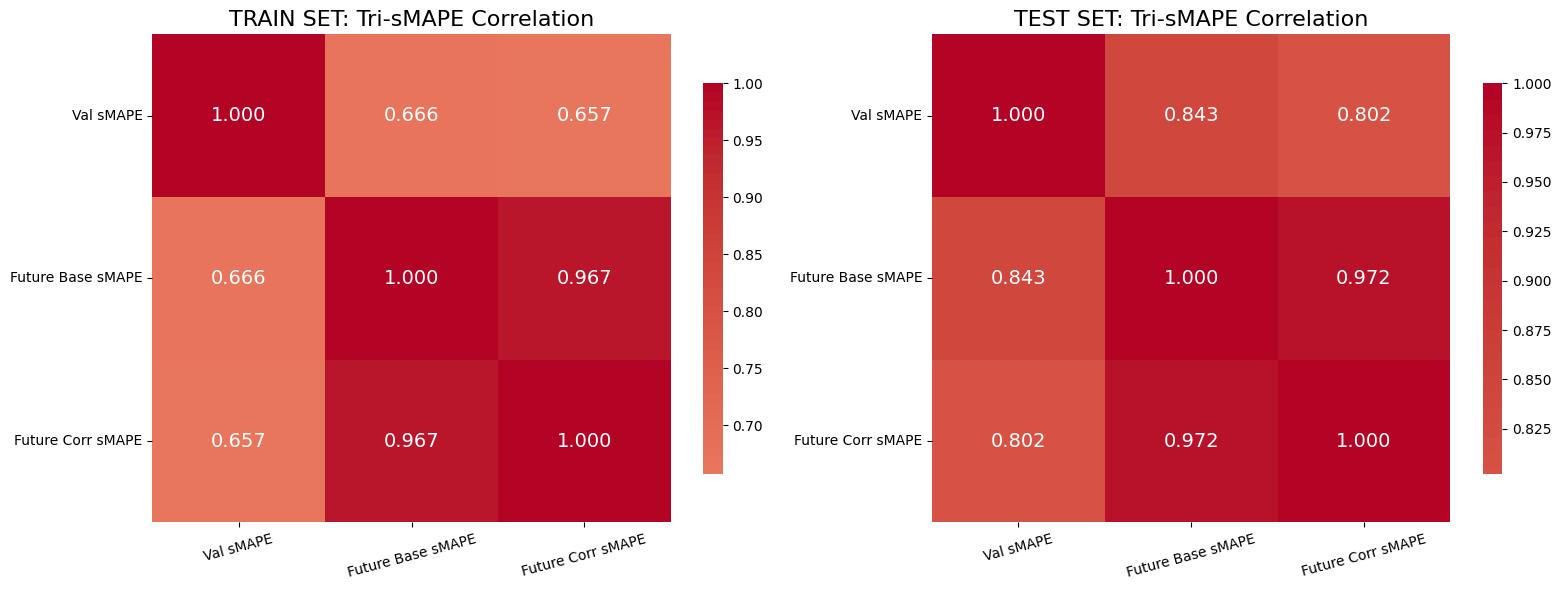

📊 正在绘制 Train Set 的三大 sMAPE 散点分布矩阵 (这可能需要几秒钟)...


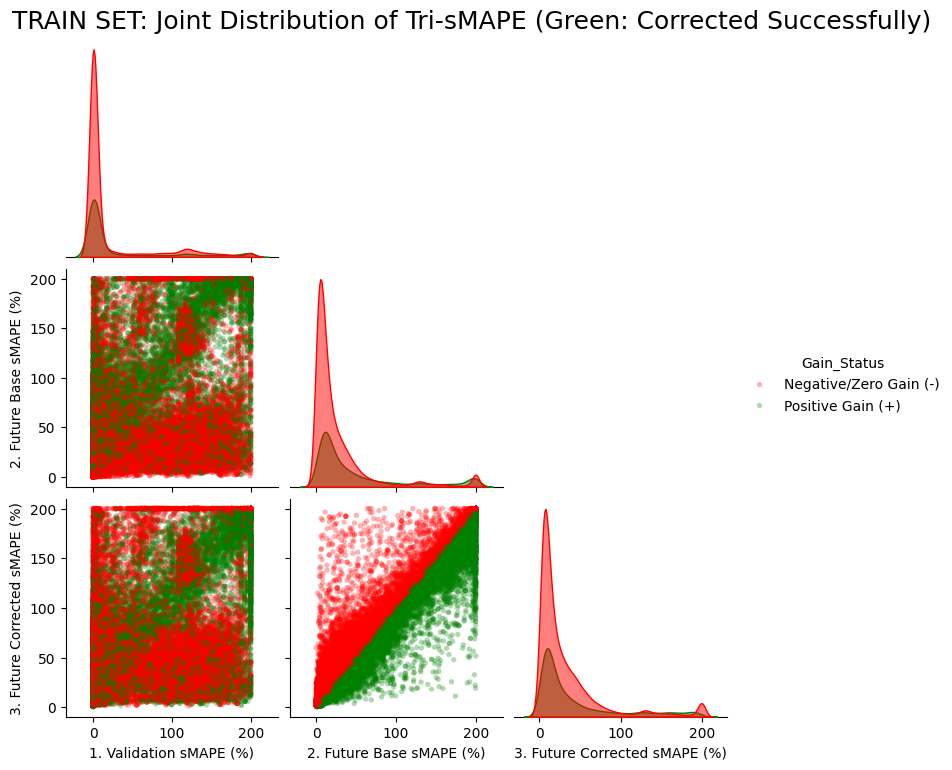

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 🌟 三大核心 sMAPE 指标关联分析 (Tri-sMAPE Correlation)
# ==========================================
error_cols = ['Val_Base_Error', 'Future_Base_Error', 'Future_Corrected_Error']
label_names = ['Val sMAPE', 'Future Base sMAPE', 'Future Corr sMAPE']

# --- 图 1：三向误差皮尔逊相关性热力图 (对比 Train 和 Test) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_train[error_cols].corr(), cmap='coolwarm', center=0, ax=axes[0], 
            annot=True, fmt=".3f", annot_kws={"size": 14}, cbar_kws={'shrink': .8})
axes[0].set_title("TRAIN SET: Tri-sMAPE Correlation", fontsize=16)
axes[0].set_xticklabels(label_names, rotation=15)
axes[0].set_yticklabels(label_names, rotation=0)

sns.heatmap(df_test[error_cols].corr(), cmap='coolwarm', center=0, ax=axes[1], 
            annot=True, fmt=".3f", annot_kws={"size": 14}, cbar_kws={'shrink': .8})
axes[1].set_title("TEST SET: Tri-sMAPE Correlation", fontsize=16)
axes[1].set_xticklabels(label_names, rotation=15)
axes[1].set_yticklabels(label_names, rotation=0)

plt.tight_layout()
plt.show()

# --- 图 2：联合分布与散点矩阵图 (Pairplot) ---
print("📊 正在绘制 Train Set 的三大 sMAPE 散点分布矩阵 (这可能需要几秒钟)...")

# 提取作图所需列
df_pairplot = df_train[error_cols + ['Label_Worth']].copy()

# 重命名列以在图表中明确标示 sMAPE (%)
rename_map = {
    'Val_Base_Error': '1. Validation sMAPE (%)',
    'Future_Base_Error': '2. Future Base sMAPE (%)',
    'Future_Corrected_Error': '3. Future Corrected sMAPE (%)',
    'Label_Worth': 'Gain_Status'
}
df_pairplot.rename(columns=rename_map, inplace=True)

# 将 0/1 标签转为文字，图例更美观
df_pairplot['Gain_Status'] = df_pairplot['Gain_Status'].map({1: 'Positive Gain (+)', 0: 'Negative/Zero Gain (-)'})

# 使用 seaborn 绘制 pairplot
pair_grid = sns.pairplot(
    df_pairplot, 
    hue='Gain_Status', 
    palette={'Positive Gain (+)': 'green', 'Negative/Zero Gain (-)': 'red'},
    plot_kws={'alpha': 0.3, 's': 15, 'edgecolor': 'none'}, 
    diag_kws={'alpha': 0.5},
    corner=True # 只画下三角，避免重复
)

pair_grid.fig.suptitle("TRAIN SET: Joint Distribution of Tri-sMAPE (Green: Corrected Successfully)", y=1.02, fontsize=18)
plt.show()

相关性图可以看到LOTSA训练集上的验证窗口可靠性比GE测试集差

红点是负收益，绿点是正收益

有很多修正后变差的样本出现在valid-corrected和valid-base图的正对角线下方，这说明很多负收益样本的形态是验证窗口上TSFM做的比未来窗口差很多。

